<a href="https://colab.research.google.com/github/notzenotz/bank-churn-prediction/blob/main/bank_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Customer Churn Prediction

Predicting which bank customers are likely to leave, and explaining why, using statistical testing, ensemble models (Random Forest, XGBoost) and SHAP.

**Dataset:** Churn Modelling (Kaggle), 10,000 customers from France, Germany and Spain. Target column: `Exited` (1 = left the bank).

**Business question:** Which customers are at risk of leaving, what drives it, and how should the bank act on it?

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Data loading

In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/bank-churn/Churn_Modelling.csv')
print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Data cleaning
Dropped `RowNumber`, `CustomerId` and `Surname`: they identify customers but carry no behaviour, and surnames could introduce bias. No missing values and no duplicates. Churn rate is 20.4%, so the classes are imbalanced (about 1 in 5).

In [5]:
df = df.drop(columns=['RowNumber','CustomerId','Surname'])
print('Jumlah baris duplikat:', df.duplicated().sum())
df.head()

Jumlah baris duplikat: 0


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
print(df['Exited'].value_counts())
print()
print((df['Exited'].value_counts(normalize=True)*100).round(2))

Exited
0    7963
1    2037
Name: count, dtype: int64

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [7]:
df.describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


## 3. Exploratory analysis
Churn rate is compared per group rather than raw counts, because group sizes differ.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

nol = df['Balance'] == 0
print(f'Nasabah saldo 0: {nol.sum()} ({nol.mean()*100:.1f}%)')
print(f'Churn rate saldo 0       :{df[nol]["Exited"].mean()*100:.1f}%')
print(f'Churn rate total > 0     :{df[~nol]["Exited"].mean()*100:.1f}%')

Nasabah saldo 0: 3617 (36.2%)
Churn rate saldo 0       :13.8%
Churn rate total > 0     :24.1%


In [9]:
for col in ['Geography','Gender','NumOfProducts','HasCrCard','IsActiveMember']:
  t = df.groupby(col)['Exited'].agg(jumlah='count', churn_rate='mean')
  t['churn_rate'] = (t['churn_rate'] * 100).round(1)
  print(t, '\n')

           jumlah  churn_rate
Geography                    
France       5014        16.2
Germany      2509        32.4
Spain        2477        16.7 

        jumlah  churn_rate
Gender                    
Female    4543        25.1
Male      5457        16.5 

               jumlah  churn_rate
NumOfProducts                    
1                5084        27.7
2                4590         7.6
3                 266        82.7
4                  60       100.0 

           jumlah  churn_rate
HasCrCard                    
0            2945        20.8
1            7055        20.2 

                jumlah  churn_rate
IsActiveMember                    
0                 4849        26.9
1                 5151        14.3 



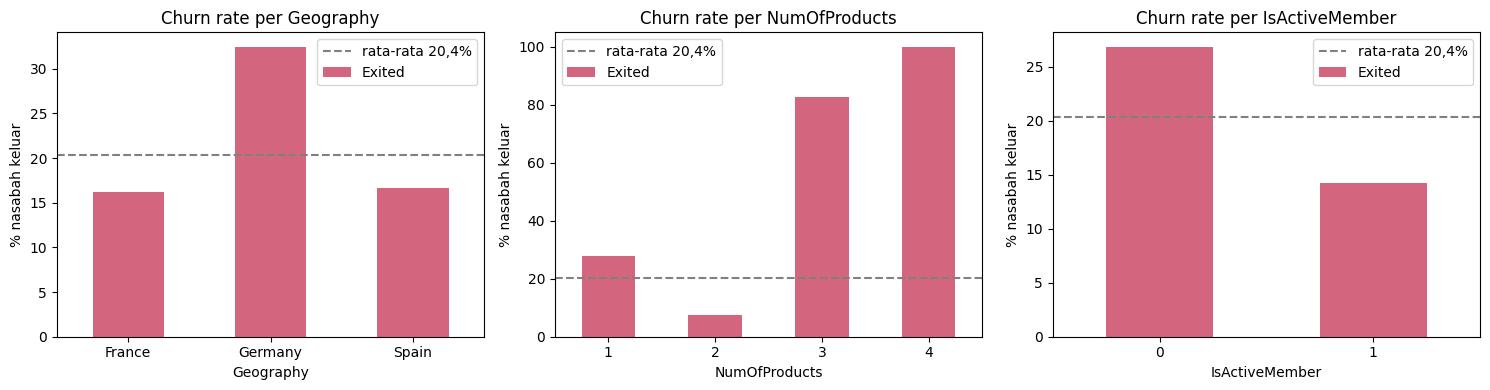

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Geography', 'NumOfProducts', 'IsActiveMember']):
  (df.groupby(col)['Exited'].mean()*100).plot(kind='bar', ax=ax, color='#D4657F')
  ax.axhline(df['Exited'].mean()*100, ls='--', color='gray', label='rata-rata 20,4%')
  ax.set_title(f'Churn rate per {col}')
  ax.set_ylabel('% nasabah keluar')
  ax.tick_params(axis='x', rotation=0)
  ax.legend()
plt.tight_layout()
plt.show()

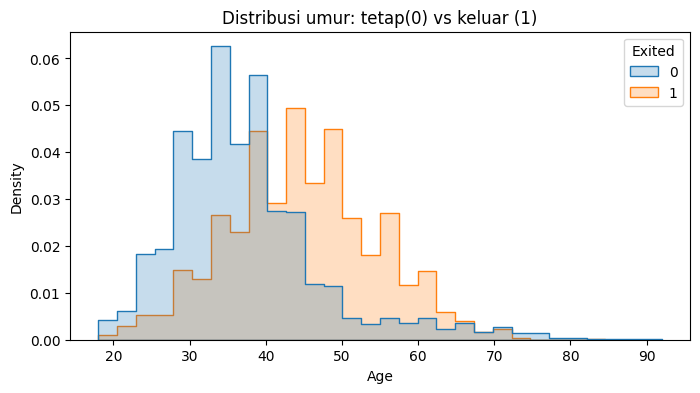

In [13]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Age', hue='Exited', bins=30, stat='density', common_norm=False, element='step')
plt.title('Distribusi umur: tetap(0) vs keluar (1)')
plt.show()

## 4. Statistical testing
Chi-square test for categorical features, Mann-Whitney U for numeric ones (Balance is far from normal: 36% of customers have a zero balance).

**Confounding check:** no German customer has a zero balance, and Germans churn the most. Comparing within the same country, customers with a balance still churn more (France 18.2% vs 13.9%, Spain 19.6% vs 13.6%), but the gap is about half of what the overall numbers suggest.

In [15]:
from scipy.stats import chi2_contingency, mannwhitneyu

print(pd.crosstab(df['Geography'], df['Balance'] == 0, margins=True))

Balance    False  True    All
Geography                    
France      2596  2418   5014
Germany     2509     0   2509
Spain       1278  1199   2477
All         6383  3617  10000


In [21]:
hasil = []
for col in ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']:
  chi2, p, dof, _ = chi2_contingency(pd.crosstab(df['Exited'], df[col]))
  hasil.append([col, 'Chi-square', round(chi2,1),p])

for col in ['Age', 'Balance', 'CreditScore', 'EstimatedSalary', 'Tenure']:
  tetap = df.loc[df['Exited'] == 0, col]
  keluar = df.loc[df['Exited'] == 1, col]
  stat, p = mannwhitneyu(tetap, keluar)
  hasil.append([col, 'Mann-Whitney U', round(stat,1),p])

uji = pd.DataFrame(hasil, columns=['Fitur', 'Uji', 'Statistik', 'p_value'])
uji['Signifikan'] = uji['p_value'] < 0.05
uji['p_value'] = uji['p_value'].map('{:.2e}'.format)
uji.sort_values('Signifikan', ascending=False)

,Fitur,Uji,Statistik,p_value,Signifikan
0,Geography,Chi-square,301.3,3.83e-66,True
1,Gender,Chi-square,112.9,2.25e-26,True
2,NumOfProducts,Chi-square,1503.6,0.00e+00,True
4,IsActiveMember,Chi-square,243.0,8.79e-55,True
5,Age,Mann-Whitney U,4345981.5,3.21e-230,True
6,Balance,Mann-Whitney U,6849444.5,1.12e-28,True
7,CreditScore,Mann-Whitney U,8381083.0,1.99e-02,True
3,HasCrCard,Chi-square,0.5,4.92e-01,False
8,EstimatedSalary,Mann-Whitney U,7969863.0,2.27e-01,False
9,Tenure,Mann-Whitney U,8272055.5,1.62e-01,False


In [23]:
(
    df.assign(SaldoNol=df['Balance'] == 0)
    .groupby(['Geography', 'SaldoNol'])['Exited']
    .mean().mul(100).round(1)
    .unstack()
)

SaldoNol,False,True
Geography,,
France,18.2,13.9
Germany,32.4,NaN
Spain,19.6,13.6


## 5. Data preparation
One-hot encoding for Geography, a binary `IsFemale` column, and a new `SaldoNol` feature (zero balance) based on the analysis above. 80/20 stratified train-test split.

In [32]:
from numpy import astype
from sklearn.model_selection import train_test_split

data = df.copy()
data['SaldoNol'] = (data['Balance'] == 0).astype(int)
data['IsFemale'] = (data['Gender'] == 'Female').astype(int)
data = data.drop(columns='Gender')
data = pd.get_dummies(data, columns=['Geography'], drop_first=True, dtype=int)

X = data.drop(columns='Exited')
y = data['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print('Train:', X_train.shape,'|Test', X_test.shape)
print(f'Churn di train: {y_train.mean()*100:.2f}% | di test: {y_test.mean()*100:.2f}%')
X.head()

Train: (8000, 12) |Test (2000, 12)
Churn di train: 20.38% | di test: 20.35%


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,SaldoNol,IsFemale,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0,1
2,502,42,8,159660.80,3,1,0,113931.57,0,1,0,0
3,699,39,1,0.00,2,0,0,93826.63,1,1,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0,1


## 6. Modelling
Logistic Regression as the baseline, compared with two ensemble models. Class imbalance handled with class weights. Evaluated with precision, recall, F1 and ROC-AUC instead of accuracy, then confirmed with 5-fold cross-validation.

In [36]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

rasio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Logistic Regression': make_pipeline(
        StandardScaler(), LogisticRegression(class_weight='balanced', max_iter=1000)),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, min_samples_leaf=5, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4, scale_pos_weight=rasio, random_state=42, eval_metric='logloss')
}

hasil = []
for nama, model in models.items():
  model.fit(X_train, y_train)
  pred = model.predict(X_test)
  prob = model.predict_proba(X_test)[:, 1]
  hasil.append([nama, precision_score(y_test, pred), recall_score(y_test, pred),
                  f1_score(y_test, pred), roc_auc_score(y_test, prob)])
skor = pd.DataFrame(hasil, columns=['Model', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'])
skor.round(3).sort_values('ROC-AUC', ascending=False)

,Model,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.512,0.747,0.607,0.867
1,Random Forest,0.629,0.641,0.635,0.863
0,Logistic Regression,0.389,0.705,0.501,0.777


In [37]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for nama, model in models.items():
    s = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f'{nama:<20} ROC-AUC: {s.mean():.3f} ± {s.std():.3f}')

Logistic Regression  ROC-AUC: 0.766 ± 0.021
Random Forest        ROC-AUC: 0.860 ± 0.011
XGBoost              ROC-AUC: 0.864 ± 0.013


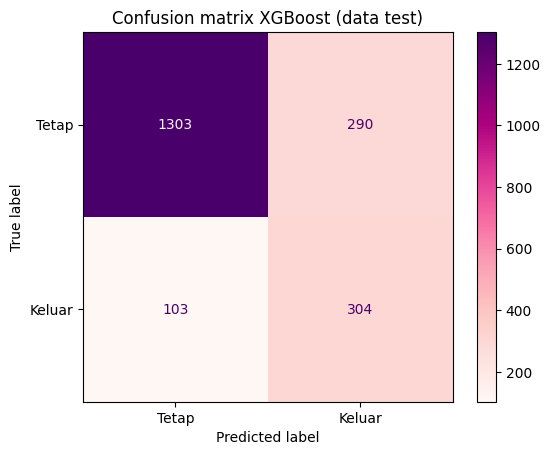

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

xgb = models['XGBoost']
ConfusionMatrixDisplay.from_estimator(
    xgb, X_test, y_test, display_labels=['Tetap', 'Keluar'], cmap='RdPu')
plt.title('Confusion matrix XGBoost (data test)')
plt.show()

## 7. Choosing a decision threshold
The model outputs a risk score, and the threshold turns it into a decision. The best threshold depends on business costs: with a cheap retention offer (Rp100k) the cheapest threshold is 0.15, with an expensive one (Rp1m) it moves to 0.80.

In [39]:
import numpy as np

prob = xgb.predict_proba(X_test)[:, 1]
rows = []
for t in np.arange(0.30, 0.81, 0.05):
    pred = (prob >= t).astype(int)
    rows.append([round(t, 2), precision_score(y_test, pred), recall_score(y_test, pred),
                 f1_score(y_test, pred), pred.sum()])

pd.DataFrame(rows, columns=['Threshold', 'Precision', 'Recall', 'F1', 'Jumlah dihubungi']).round(3)

,Threshold,Precision,Recall,F1,Jumlah dihubungi
0,0.30,0.369,0.880,0.520,970
1,0.35,0.409,0.850,0.553,845
2,0.40,0.440,0.818,0.572,757
3,0.45,0.475,0.779,0.590,668
4,0.50,0.512,0.747,0.607,594
5,0.55,0.546,0.708,0.617,527
6,0.60,0.595,0.668,0.630,457
7,0.65,0.640,0.607,0.623,386
8,0.70,0.701,0.577,0.633,335
9,0.75,0.754,0.521,0.616,281


In [51]:
RUGI_PER_NASABAH = 2_000_000   # kerugian kalau 1 nasabah keluar
BIAYA_PROMO = 100_000     # biaya menghubungi + promo per nasabah

total_churn = y_test.sum()
rows = []
for t in np.arange(0.05, 0.96, 0.05):
    pred = (prob >= t).astype(int)
    tangkap = ((pred == 1) & (y_test == 1)).sum()
    kecolongan = total_churn - tangkap
    dihubungi = pred.sum()
    biaya = kecolongan * RUGI_PER_NASABAH + dihubungi * BIAYA_PROMO
    rows.append([round(t, 2), dihubungi, tangkap, kecolongan, biaya / 1e6])

biaya_df = pd.DataFrame(rows, columns=['Threshold', 'Dihubungi', 'Ketangkep', 'Kecolongan', 'Total biaya (juta Rp)'])
terbaik = biaya_df.loc[biaya_df['Total biaya (juta Rp)'].idxmin()]
print(f"Threshold paling hemat: {terbaik['Threshold']} dengan total biaya Rp {terbaik['Total biaya (juta Rp)']:.0f} juta")
biaya_df.round(1)

Threshold paling hemat: 0.15 dengan total biaya Rp 170 juta


,Threshold,Dihubungi,Ketangkep,Kecolongan,Total biaya (juta Rp)
0,0.0,1817,403,4,189.7
1,0.1,1581,400,7,172.1
2,0.2,1376,391,16,169.6
3,0.2,1198,380,27,173.8
4,0.2,1079,373,34,175.9
5,0.3,970,358,49,195.0
6,0.4,845,346,61,206.5
7,0.4,757,333,74,223.7
8,0.4,668,317,90,246.8
9,0.5,594,304,103,265.4


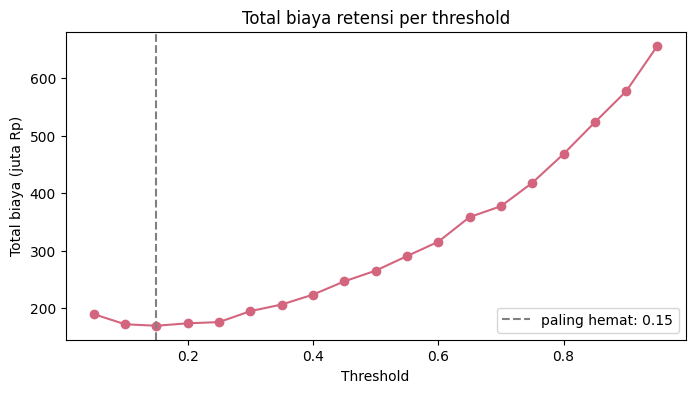

In [52]:
plt.figure(figsize=(8, 4))
plt.plot(biaya_df['Threshold'], biaya_df['Total biaya (juta Rp)'], marker='o', color='#D4657F')
plt.axvline(terbaik['Threshold'], ls='--', color='gray', label=f"paling hemat: {terbaik['Threshold']}")
plt.xlabel('Threshold')
plt.ylabel('Total biaya (juta Rp)')
plt.title('Total biaya retensi per threshold')
plt.legend()
plt.show()

## 8. Explaining the model with SHAP

In [53]:
!pip install -q -U shap

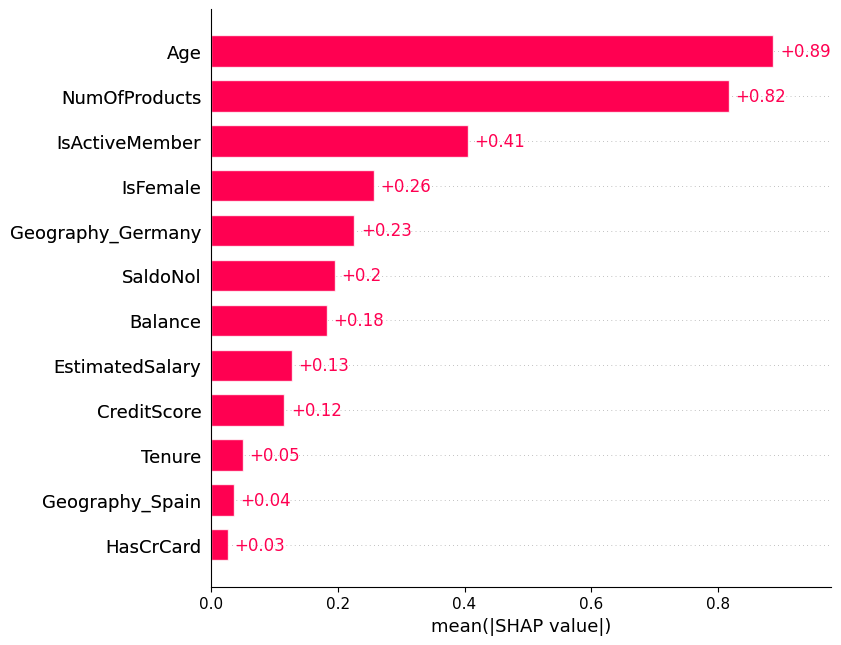

In [54]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_test)

shap.plots.bar(shap_values, max_display=12)

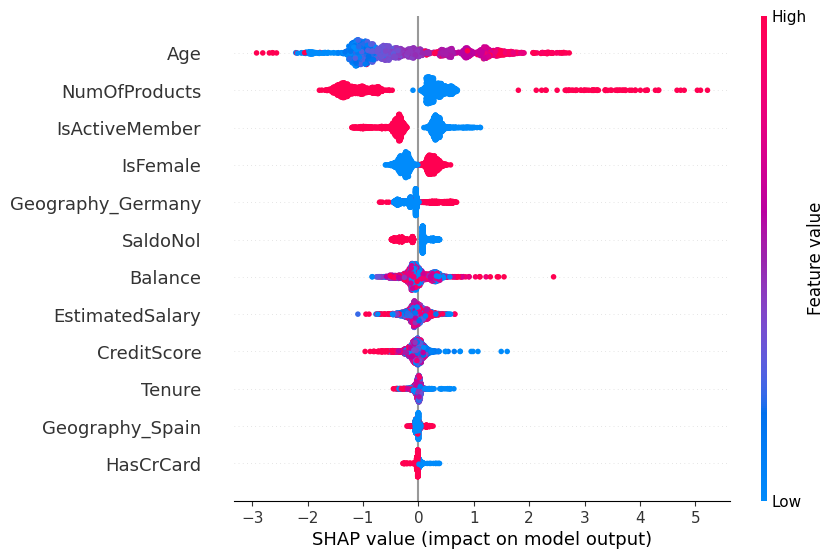

In [55]:
shap.plots.beeswarm(shap_values, max_display=12)

Skor risiko: 1.0 | Beneran keluar? 1


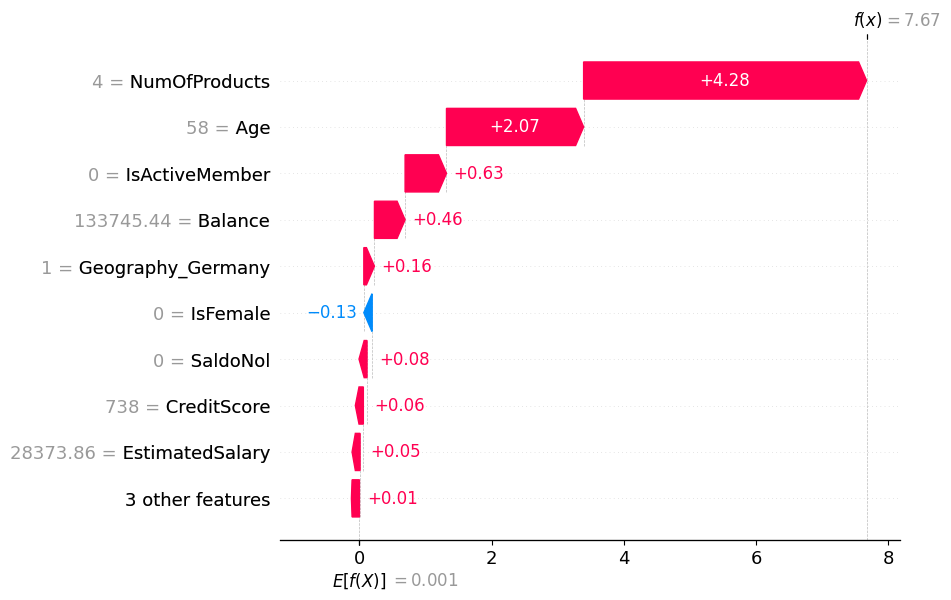

In [56]:
i = int(np.argmax(prob))
print('Skor risiko:', round(float(prob[i]), 3), '| Beneran keluar?', int(y_test.iloc[i]))
shap.plots.waterfall(shap_values[i])

## 9. Business recommendations

| Finding | Recommendation |
|---|---|
| Customers with 3–4 products churn 83–100% | Review product bundling: customers may be holding products they don't need |
| Inactive members churn almost twice as often | Re-activation programme: reminders and first-transaction cashback |
| Ages 45–60 are the highest-risk group | Pre-retirement offers: investment, pension and priority service |
| German customers churn 32% | Investigate the German market: competitors, branch service, fees |
| Customers with a balance churn more | Rate or benefit offers for high-balance customers before competitors reach them |
| The model catches 75% of leaving customers | Use risk scores to prioritise the retention team's call list |

## 10. Limitations
- The 4-product group has only 60 customers, so its 100% churn rate needs verification.
- Retention costs in the threshold analysis are assumptions, not real bank figures.
- The model still uses `EstimatedSalary`, which was not significant in testing; it is a candidate to drop.
- Public dataset from three European countries; results may not transfer to Indonesian banks.